# 📊 Análisis Estadístico de Commits - dgsuc-app

Este notebook analiza el historial de commits exportado a `commits_data.csv` para visualizar patrones de trabajo, horarios de mayor productividad y evolución del proyecto.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración estética
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carga y Preparación de Datos

In [2]:
# Cargar el CSV generado previamente
df = pd.read_csv('commits_data.csv', names=['hash', 'timestamp'])

# Convertir a datetime (UTC para consistencia)
df['date'] = pd.to_datetime(df['timestamp'], utc=True)

# Extraer dimensiones temporales
df['hour'] = df['date'].dt.hour
df['day_name'] = df['date'].dt.day_name()
df['is_weekend'] = df['date'].dt.dayofweek >= 5
df['month_year'] = df['date'].dt.to_period('M')
df['date_only'] = df['date'].dt.date

print(f"Total de commits cargados: {len(df)}")
df.head()

Total de commits cargados: 829


/tmp/ipykernel_887836/3334176373.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month_year'] = df['date'].dt.to_period('M')


,hash,timestamp,date,hour,day_name,is_weekend,month_year,date_only
0,473e01c,2026-01-29T22:09:00-03:00,2026-01-30 01:09:00+00:00,1,Friday,False,2026-01,2026-01-30
1,f1e2c9d,2026-01-25T16:30:09-03:00,2026-01-25 19:30:09+00:00,19,Sunday,True,2026-01,2026-01-25
2,f80a993,2026-01-25T16:09:03-03:00,2026-01-25 19:09:03+00:00,19,Sunday,True,2026-01,2026-01-25
3,2abedcf,2026-01-25T14:24:38-03:00,2026-01-25 17:24:38+00:00,17,Sunday,True,2026-01,2026-01-25
4,c26c152,2026-01-24T20:46:18-03:00,2026-01-24 23:46:18+00:00,23,Saturday,True,2026-01,2026-01-24


## 2. Histograma por Hora del Día
¿A qué hora del día sueles programar más?

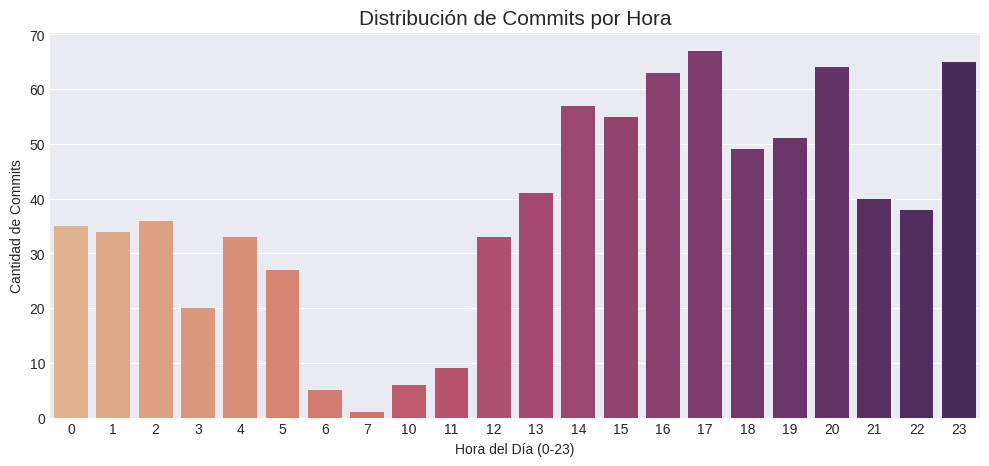

In [3]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='hour', hue='hour', palette='flare', legend=False)
plt.title('Distribución de Commits por Hora', fontsize=15)
plt.xlabel('Hora del Día (0-23)')
plt.ylabel('Cantidad de Commits')
plt.show()

## 3. Actividad por Día de la Semana
¿Cuáles son tus días más productivos?

/tmp/ipykernel_887836/1153138251.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='day_name', order=days_order, palette='mako')


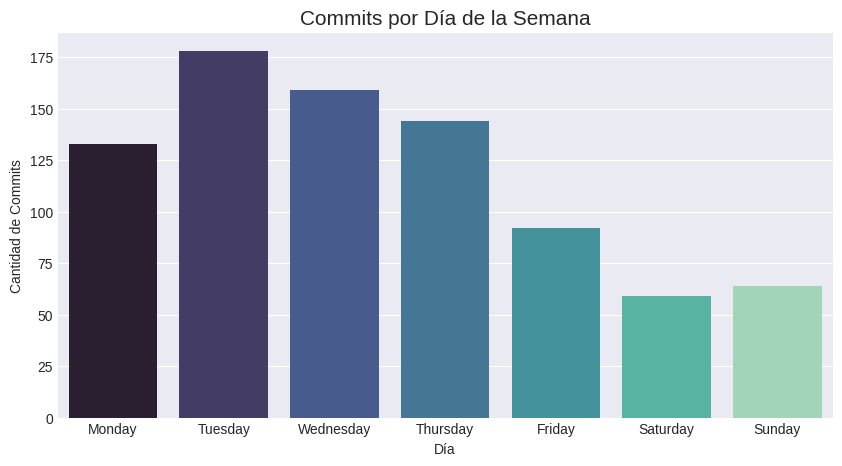

In [4]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='day_name', order=days_order, palette='mako')
plt.title('Commits por Día de la Semana', fontsize=15)
plt.xlabel('Día')
plt.ylabel('Cantidad de Commits')
plt.show()

## 4. Evolución Temporal (Timeline)
¿Cómo ha avanzado el proyecto mes a mes?

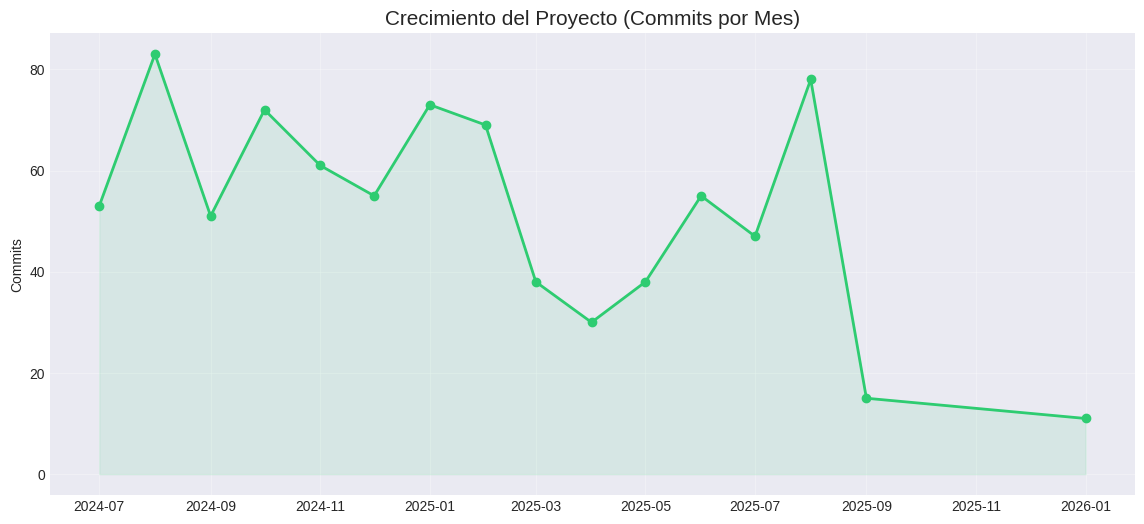

In [5]:
timeline = df.groupby('month_year').size()
timeline.index = timeline.index.to_timestamp()

plt.figure(figsize=(14, 6))
plt.plot(timeline.index, timeline.values, marker='o', linestyle='-', linewidth=2, color='#2ecc71')
plt.fill_between(timeline.index, timeline.values, color='#2ecc71', alpha=0.1)
plt.title('Crecimiento del Proyecto (Commits por Mes)', fontsize=15)
plt.ylabel('Commits')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Heatmap de Actividad (Punch Card)
Relación entre Día y Hora.

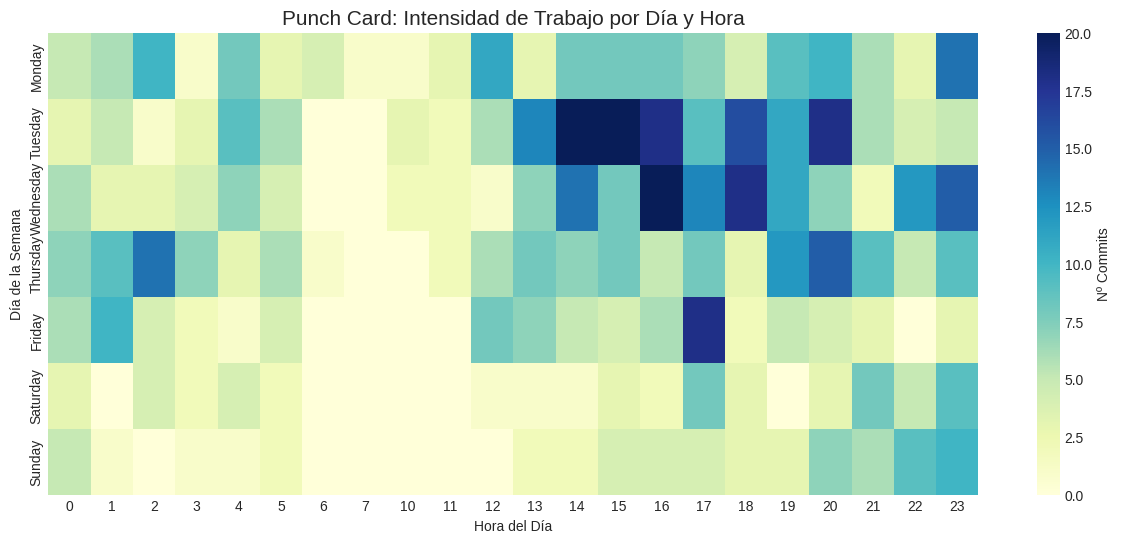

In [6]:
punch_card = df.groupby(['day_name', 'hour']).size().unstack(fill_value=0)
punch_card = punch_card.reindex(days_order)

plt.figure(figsize=(15, 6))
sns.heatmap(punch_card, cmap="YlGnBu", annot=False, cbar_kws={'label': 'Nº Commits'})
plt.title('Punch Card: Intensidad de Trabajo por Día y Hora', fontsize=15)
plt.xlabel('Hora del Día')
plt.ylabel('Día de la Semana')
plt.show()